In [37]:
import os
from pathlib import Path
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
import cil_regionalization as cilreg
from cil_regionalization.config import SourceUnitPolicies

DATA = Path("/home/emily_zuetell/projects/poreallas/data")
DATA_VERSION = "world-combo-201710"  # the impact region version of the sample

In [33]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
#EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
#EFFECTS_URI = os.path.join(DATA_DIR, "260828_effects.zarr") # Local version 

# Total Running Effects
EFFECTS_URI = "2608_effects_running_total.zarr"

IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [34]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [46]:
def ir_to_adm1(
    effect,
    polygons,
    rate=False,
    hotonly="net",
    monthly=True,
    months = [1, 8, 9, 10, 11, 12],
    dims=["number", "sample"],
    operation="median",
):
    # Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
    impact = analysis_utils.compute_impact(
        effect,
        socioeconomics,
        ensemble=True,
        baseline_period=baseline_period,
        hotonly=hotonly,
        rate=rate,
        age_weight=True,
    )

    if not monthly:
        impact_s = impact.sel(month=months).sum(dim="month")
    else:
        impact_s = impact.sel(month=months)

    if operation == "median":
        impact_s = impact_s.median(dim=dims)
    elif operation == "mean":
        impact_s = impact_s.mean(dim=dims)

    _polygons_impact = analysis_utils.xarray_to_gpd(impact_s, polygons)
    shapes = gpd.read_parquet(DATA / "adm1.parquet")
    # names = shapes[["ISO", "ID_1", "NAME_1"]]
    names = shapes[["GID_0", "GID_1", "NAME_1"]]
    # Total Deaths: "per_source", "kind = extensive"
    # Death Rates: "per_destination", "kind = intensive"
    if rate:
        weights = cilreg.fetch_weights("gadm41-adm1-per-destination")
    else:
        weights = cilreg.fetch_weights("gadm41-adm1-per-source")

    damages = (
        _polygons_impact[["region", "month", "age_weighted_impact"]]
        if monthly
        else _polygons_impact[["region", "age_weighted_impact"]]
    )
    damages = damages.rename(columns={"region": "hierid"})
    col_regions = {(h,) for h in damages["hierid"].unique()}
    # allow_partial_coverage=True to handle coastal geometry
    kind = "intensive" if rate else "extensive"

    _damages = damages
    adm1 = cilreg.apply_weights(
        weights,
        _damages,
        kind=kind,
        weight="pop",
        value_col="age_weighted_impact",
        data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
        allow_partial_coverage=True,
        policies=SourceUnitPolicies(on_unmatched="skip", on_zero_weight="skip"),
    ).frame

    m = shapes.merge(adm1, on=["GID_0", "GID_1"])

    return m

In [48]:
# Running Total (June, July)
monthly = False
hotonly = 'hotonly'

m_running_hot = ir_to_adm1(
    effect,
    _polygons,
    rate=False,
    hotonly=hotonly,
    monthly=monthly,
    months=[6, 7],
    dims=["sample"],
    operation="mean",
)
m_running_hot["Hot Deaths"] = m_running_hot["age_weighted_impact"].round(0).astype(int)

hotonly = 'net'

m_running_net = ir_to_adm1(
    effect,
    _polygons,
    rate=False,
    hotonly=hotonly,
    monthly=monthly,
    months=[6, 7],
    dims=["sample"],
    operation="mean",
)
m_running_net["Net Deaths"] = m_running_net["age_weighted_impact"].round(0).astype(int)

source coverage: 3 unmatched source units (first 3: [['IND.12.129.431'], ['IND.12.129.432'], ['VNM.4.37.365.6048']]); recorded in the manifest and skipped
source coverage: 3 unmatched source units (first 3: [['IND.12.129.431'], ['IND.12.129.432'], ['VNM.4.37.365.6048']]); recorded in the manifest and skipped


In [51]:
out = m_running_hot.merge(m_running_net[["GID_0", "GID_1", "NAME_0", "NAME_1", "Net Deaths"]], on=["GID_0", "GID_1", "NAME_0", "NAME_1"])

In [58]:
out[["GID_0", "GID_1", "NAME_0", "NAME_1", "Hot Deaths", "Net Deaths"]].to_csv("260828_running_total_adm1.csv", index=False)

In [22]:
monthly = True
hotonly = 'coldonly'

m_cold = ir_to_adm1(
    effect,
    _polygons,
    rate=False,
    hotonly=hotonly,
    monthly=monthly,
    months=[1, 8, 9, 10, 11, 12],
    dims=["number", "sample"],
    operation="median",
)
m_cold["Cold Deaths"] = m_cold["age_weighted_impact"].astype(int)

source coverage: 3 unmatched source units (first 3: [['IND.12.129.431'], ['IND.12.129.432'], ['VNM.4.37.365.6048']]); recorded in the manifest and skipped


In [ ]:
monthly = True
hotonly = 'hotonly'

m_hot = ir_to_adm1(
    effect,
    _polygons,
    rate=False,
    hotonly=hotonly,
    monthly=monthly,
    months=[1, 8, 9, 10, 11, 12],
    dims=["number", "sample"],
    operation="median",
)
m_hot["Heat Deaths"] = m_hot["age_weighted_impact"].astype(int)

source coverage: 3 unmatched source units (first 3: [['IND.12.129.431'], ['IND.12.129.432'], ['VNM.4.37.365.6048']]); recorded in the manifest and skipped


In [24]:
out = m_hot[['GID_0', 'GID_1', 'NAME_0', 'NAME_1', 'month', 'Heat Deaths']]
out = out.merge(m_cold[['GID_0', 'GID_1', 'NAME_0', 'NAME_1', 'month', 'Cold Deaths']], on=['GID_0', 'GID_1', 'NAME_0', 'NAME_1', 'month'], suffixes=('_hot', '_cold'))
month_names = {1: "Jan 2027", 8: "Aug 2026", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
out["month"] = out["month"].map(month_names)

In [26]:
out.to_csv("vis3_2.csv", index=False)

In [52]:
if monthly:
    wide = m.pivot(
        index=["GID_0", "GID_1"], columns="month", values='age_weighted_impact'
    )
    wide = wide.reset_index()

    monthly_l = "monthly" 
    wide[['GID_0', 'GID_1', 1, 8, 9, 10, 11, 12]].to_csv(
        f"260828_{monthly_l}_{hotonly}_total_median_adm1.csv", 
        index=False
    )
else:
    monthly_l = "6mo"
    m[['GID_0', 'GID_1', 'age_weighted_impact']].to_csv(
        f"260828_{monthly_l}_{hotonly}_total_median_adm1.csv", 
        index=False
    )

<Axes: >

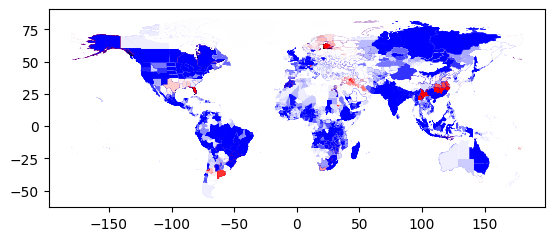

In [8]:
m.plot(column="age_weighted_impact", vmin=-15, vmax=15, cmap="bwr")

# Validation

In [ ]:
# Compare totals for IR and ADM1
for iso in ["AUS"]:
    adm1_iso = m[m["GID_0"] == iso]["age_weighted_impact"].sum()
    ir_iso = _polygons_impact[_polygons_impact["ISO"] == iso][
        "age_weighted_impact"
    ].sum()
    print(f"{iso}\nIR Total: {ir_iso}\n ADM1 Total: {adm1_iso}")

<Axes: >

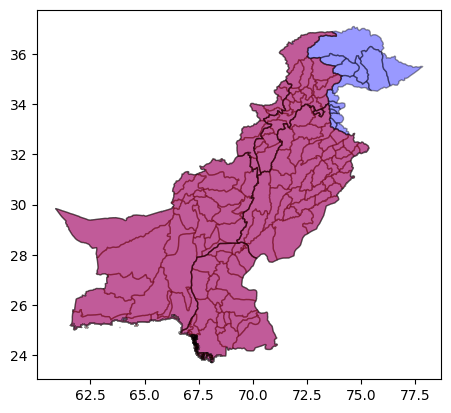

In [ ]:
# Compare Geometry Outlines
iso = "PAK"
fig, ax = plt.subplots()
_polygons_impact[_polygons_impact["ISO"] == iso].to_crs("WGS 84").plot(
    color="blue", alpha=0.4, edgecolor="k", ax=ax
)
m[m["GID_0"] == iso].plot(color="red", edgecolor="k", alpha=0.4, ax=ax)

<Axes: >

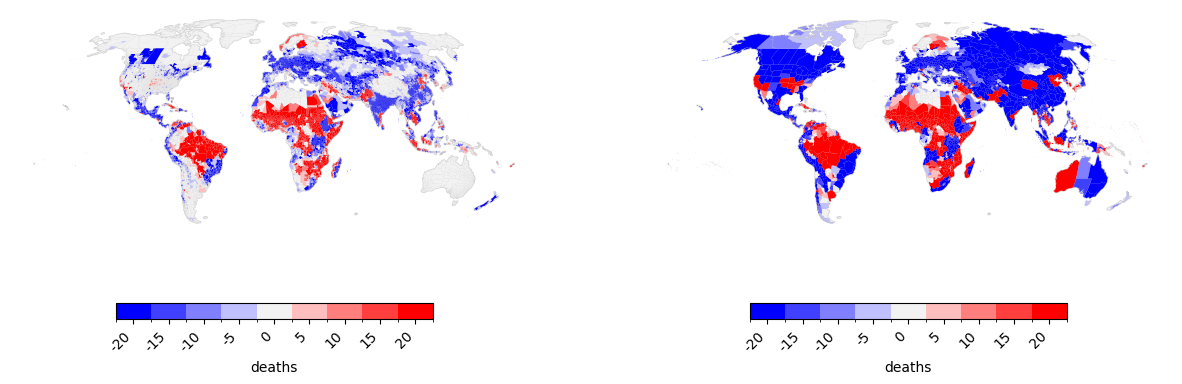

In [ ]:
# Compare Maps
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

analysis_utils.plot_single(
    _polygons_impact,
    col="age_weighted_impact",
    cm="bwr",
    n_colors=10,
    vmin=-20,
    vmax=20,
    sup_title="",
    cbar_label="deaths/100k" if rate else "deaths",
    cbar_location="bottom",
    ax=axs[0],
)

analysis_utils.plot_single(
    m,
    col="age_weighted_impact",
    cm="bwr",
    n_colors=10,
    vmin=-20,
    vmax=20,
    sup_title="",
    cbar_label="deaths/100k" if rate else "deaths",
    cbar_location="bottom",
    ax=axs[1],
)